# Project 06: load and inspect Norman 2019

Step 4 already completed in your setup notebook: GEARS downloaded the data and loaded **89,357 cells and 5,045 measured genes**.

This notebook completes the first inspection and saves a plot and condition-count table. Norman 2019 uses **CRISPR activation**, which increases target gene activity.

Run these cells from top to bottom with your existing **Python 3.10** kernel. They use the downloaded files. The expression matrix stays on disk during this inspection, so we do not reload the large GEARS graph cache into memory.


In [1]:
from pathlib import Path
import json
import pickle
from importlib.metadata import version

import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Image

project_dir = Path.cwd()
data_dir = project_dir / "data"
results_dir = project_dir / "results"
results_dir.mkdir(exist_ok=True)

print("Project folder:", project_dir)
for package in ["torch", "torch_geometric", "cell-gears", "scanpy", "anndata"]:
    print(f"{package}: {version(package)}")


Project folder: <project folder>
torch: 2.14.1
torch_geometric: 2.8.0.post1
cell-gears: 0.1.2
scanpy: 1.11.5
anndata: 0.11.4


## Read the local dataset

`backed="r"` opens the expression file for reading without loading its full matrix into memory. We apply the same gene-graph eligibility rule used by the installed GEARS loader. Conditions targeting genes outside that graph are excluded; this is a filter, not a download error.

The `.pkl` files below are the local reference files already downloaded by your GEARS loader.


In [2]:
dataset_path = data_dir / "norman" / "perturb_processed.h5ad"
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}. Open this notebook from the project folder.")

raw_adata = ad.read_h5ad(dataset_path, backed="r")
with (data_dir / "gene2go_all.pkl").open("rb") as file:
    gene2go = pickle.load(file)
with (data_dir / "essential_all_data_pert_genes.pkl").open("rb") as file:
    reference_genes = pickle.load(file)

supported_genes = set(reference_genes).intersection(gene2go)

def supported_condition(condition):
    return all(gene == "ctrl" or gene in supported_genes
               for gene in str(condition).split("+"))

keep = raw_adata.obs["condition"].map(supported_condition).to_numpy(dtype=bool)
excluded_conditions = sorted(raw_adata.obs.loc[~keep, "condition"].unique().tolist())
adata = raw_adata[keep, :]
observations = adata.obs.copy()

print(f"Cells in downloaded file: {raw_adata.n_obs:,}")
print(f"Cells retained by GEARS filter: {adata.n_obs:,}")
print(f"Measured genes: {adata.n_vars:,}")
print("Excluded condition labels:", excluded_conditions)

assert adata.shape == (89357, 5045), "Loaded counts differ from the saved GEARS run; investigate before modeling."


Cells in downloaded file: 91,205
Cells retained by GEARS filter: 89,357
Measured genes: 5,045
Excluded condition labels: ['IER5L+ctrl', 'KIAA1804+ctrl', 'LYL1+IER5L', 'RHOXF2BB+SET', 'RHOXF2BB+ZBTB25', 'RHOXF2BB+ctrl', 'ctrl+IER5L']


## Count the conditions

A **cell** is one row of measurements. A **condition** is the perturbation applied to a group of cells. `ctrl` denotes the control group. A label such as `GENE+ctrl` targets one gene, while `GENE_A+GENE_B` targets two.

Counts here refer to the condition labels in this processed dataset; labels with different guide positions can appear separately. Before a modeling split, we will check equivalent labels so the same biological pair cannot span train and test.


In [3]:
condition_counts = observations["condition"].value_counts().sort_values(ascending=False)
condition_counts = condition_counts[condition_counts > 0]

def condition_type(condition):
    targets = [gene for gene in str(condition).split("+") if gene != "ctrl"]
    return {0: "control", 1: "single gene", 2: "gene pair"}[len(targets)]

condition_table = condition_counts.rename_axis("condition").reset_index(name="cells")
condition_table["type"] = condition_table["condition"].map(condition_type)

print(f"Condition labels with cells: {len(condition_table):,}")
display(condition_table.head(20))
display(condition_table.groupby("type", sort=False).agg(
    condition_labels=("condition", "size"), cells=("cells", "sum")
))

assert int(condition_table["cells"].sum()) == adata.n_obs
condition_table.to_csv(results_dir / "condition_counts.csv", index=False)


Condition labels with cells: 277


,condition,cells,type
0,ctrl,7353,control
1,CEBPE+RUNX1T1,1030,gene pair
2,KLF1+ctrl,997,single gene
3,TBX3+TBX2,969,gene pair
4,SLC4A1+ctrl,853,single gene
5,ETS2+CNN1,785,gene pair
6,DUSP9+ETS2,698,gene pair
7,UBASH3B+OSR2,677,gene pair
8,DUSP9+ctrl,662,single gene
9,ctrl+ETS2,656,single gene


,condition_labels,cells
type,,
control,1,7353
gene pair,128,34426
single gene,148,47578


## First plot: cells per condition

This shows the 20 conditions with the most cells. Unequal counts matter: when we evaluate pair predictions later, we will average errors per pair so a condition with more cells does not dominate the score.


Saved: <project folder>/results/cells_per_condition.png


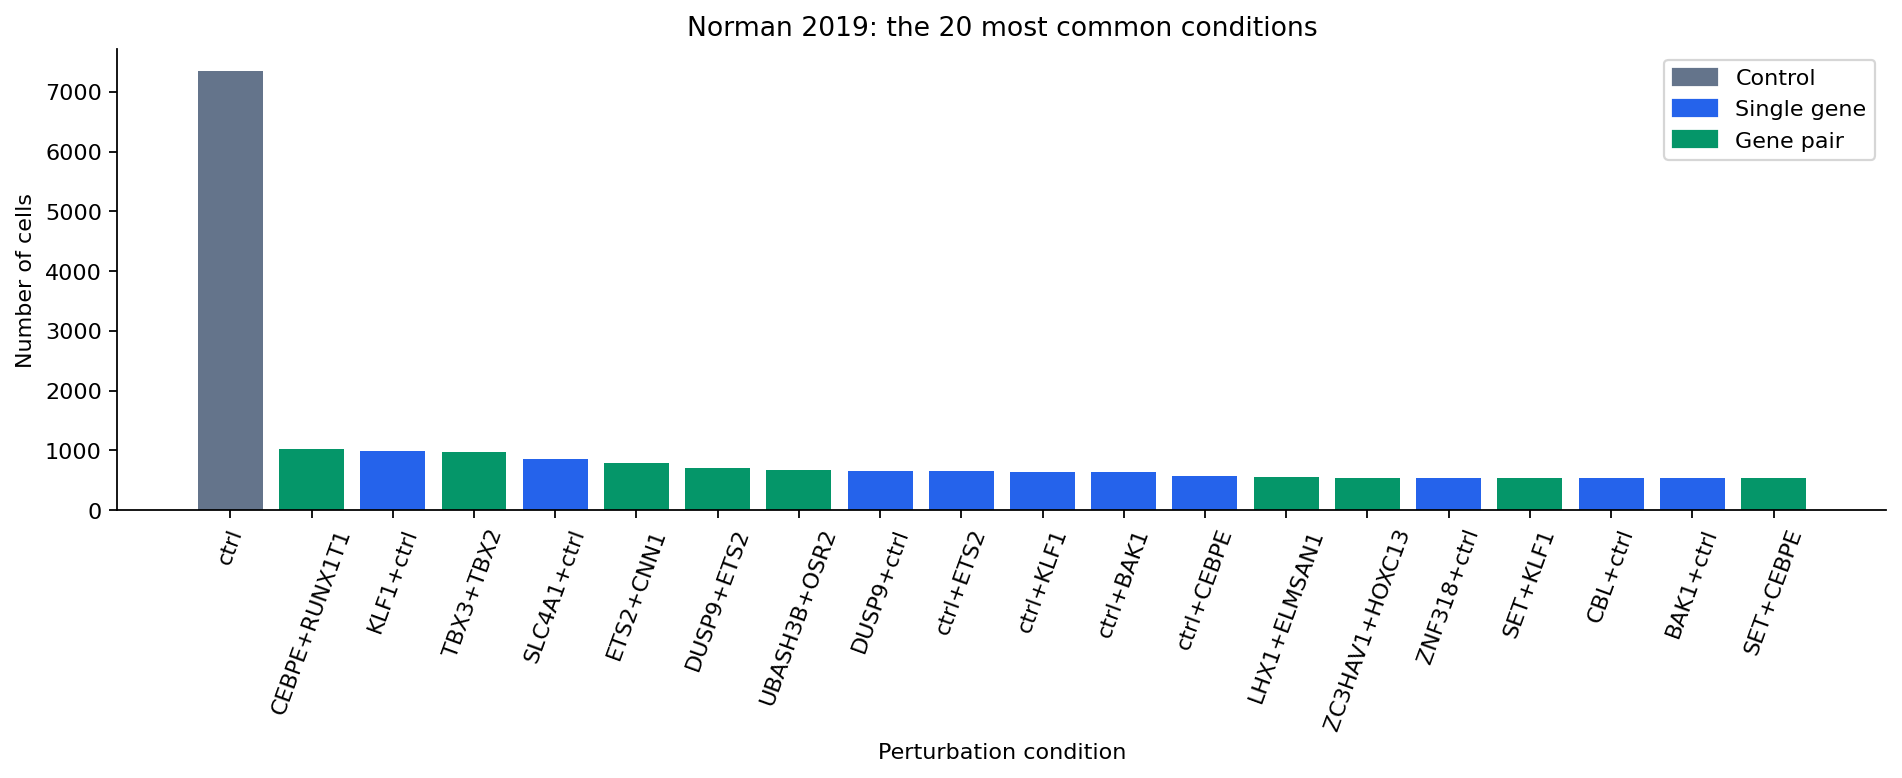

In [4]:
top_conditions = condition_table.head(20)
colors = top_conditions["type"].map({
    "control": "#64748b", "single gene": "#2563eb", "gene pair": "#059669"
})
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_conditions["condition"], top_conditions["cells"], color=colors)
ax.set_ylabel("Number of cells")
ax.set_xlabel("Perturbation condition")
ax.set_title("Norman 2019: the 20 most common conditions")
ax.legend(handles=[
    Patch(color="#64748b", label="Control"),
    Patch(color="#2563eb", label="Single gene"),
    Patch(color="#059669", label="Gene pair"),
])
ax.tick_params(axis="x", labelrotation=70)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plot_path = results_dir / "cells_per_condition.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(plot_path)))
print("Saved:", plot_path)


## Save the dataset summary

These are inspection results. No prediction model has been trained and there are no model performance scores yet.


In [5]:
summary = {
    "dataset": "Norman 2019 (GEARS processed)",
    "perturbation_method": "CRISPR activation",
    "downloaded_cells": int(raw_adata.n_obs),
    "gears_eligible_cells": int(adata.n_obs),
    "measured_genes": int(adata.n_vars),
    "condition_labels": int(len(condition_table)),
    "excluded_condition_labels": excluded_conditions,
    "model_trained": False,
}
(results_dir / "dataset_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
packages = ["torch", "torch_geometric", "cell-gears", "scanpy", "anndata",
            "numpy", "pandas", "matplotlib", "scikit-learn", "scipy"]
(results_dir / "environment_versions.txt").write_text(
    "\n".join(f"{package}=={version(package)}" for package in packages) + "\n"
)
print("Steps 4 and 5 complete: dataset verified, condition counts saved, and plot created.")
print("Next: make a split by whole perturbation conditions and calculate the additive baseline.")
raw_adata.file.close()


Steps 4 and 5 complete: dataset verified, condition counts saved, and plot created.
Next: make a split by whole perturbation conditions and calculate the additive baseline.


## Next milestone

1. Check and group equivalent perturbation labels.
2. Keep all cells from each test gene pair outside training; ensure the required single-gene conditions are available in training.
3. Predict each held-out pair with `mean(A) + mean(B) - mean(control)` using training data only.
4. Compare this additive baseline with GEARS on the same test pairs and evaluation genes.

The original setup notebooks are preserved. For training later, the standard `PertData.load()` call will reload the cached GEARS cell graphs; those graphs are several gigabytes, so training uses more memory than this inspection notebook.
